# REZ wind drought duration distribution: ERA5 vs all BARRA-RE2 realizations

This notebook plots the **full BARRA-RE2 ensemble**, not only the pooled BARRA distribution or the ensemble mean.

Best-practice ensemble display used here:

1. **All 22 BARRA-RE2 realizations** are shown as thin light-grey step lines.
2. **BARRA-RE2 ensemble spread** is shown as a 10-90% shaded band.
3. **BARRA-RE2 ensemble-mean probability distribution** is shown as a thick black line.
4. **ERA5** is shown as a thick coloured line.
5. A second difference plot shows **BARRA-RE2 minus ERA5** for each member and for the ensemble mean.

Why this is better than a bar graph:

- 22 grouped bars become visually crowded.
- Grey ensemble members show the real spread across realizations.
- The mean line shows the central tendency.
- ERA5 stays visible for direct comparison.
- The difference plot shows whether BARRA has more or fewer events at each duration.


In [1]:
import os
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


In [2]:
# =====================
# Paths
# =====================
era5_wd_dir = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"
barra_wd_dir = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly"
rez_file = "/g/data/ng72/ri9247/data/masks/rez_mask_ERA5.nc"

output_dir = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/ensemble_realization_comparison"
os.makedirs(output_dir, exist_ok=True)

start_year = 1990
end_year = 2025

lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

print("Output directory:", output_dir)


Output directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/ensemble_realization_comparison


In [3]:
# =====================
# Helper functions
# =====================
def standardise_lon_lat_names(da):
    # Rename latitude/longitude to lat/lon if needed.
    rename = {}

    if "longitude" in da.dims:
        rename["longitude"] = "lon"
    if "latitude" in da.dims:
        rename["latitude"] = "lat"

    if "longitude" in da.coords:
        rename["longitude"] = "lon"
    if "latitude" in da.coords:
        rename["latitude"] = "lat"

    if len(rename) > 0:
        da = da.rename(rename)

    return da


def get_first_data_var(ds, preferred="wind_drought"):
    # Return preferred variable if present, otherwise first data variable.
    if preferred in ds.data_vars:
        return preferred
    return list(ds.data_vars)[0]


def event_durations_1d(mask):
    # Return durations of consecutive 1-runs in a 1D binary mask.
    # The mask should already be the final 3-day drought mask.
    mask = np.asarray(mask, dtype=np.int8)

    padded = np.pad(mask, (1, 1), mode="constant", constant_values=0)
    changes = np.diff(padded)

    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]

    durations = ends - starts
    return durations.tolist()


def files_for_years(input_dir):
    files = sorted(glob(os.path.join(input_dir, "wind_drought_P20_3day_*.nc")))

    selected = []
    for fp in files:
        year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
        if start_year <= year <= end_year:
            selected.append(fp)

    if len(selected) == 0:
        raise FileNotFoundError(f"No files found in {input_dir} for {start_year}-{end_year}")

    return selected


def summarize_durations(name, durations):
    durations = np.asarray(durations)

    if len(durations) == 0:
        return {
            "dataset": name,
            "number_of_events": 0,
            "mean_duration_days": np.nan,
            "median_duration_days": np.nan,
            "p90_duration_days": np.nan,
            "p95_duration_days": np.nan,
            "max_duration_days": np.nan,
        }

    return {
        "dataset": name,
        "number_of_events": int(len(durations)),
        "mean_duration_days": float(np.mean(durations)),
        "median_duration_days": float(np.median(durations)),
        "p90_duration_days": float(np.percentile(durations, 90)),
        "p95_duration_days": float(np.percentile(durations, 95)),
        "max_duration_days": int(np.max(durations)),
    }


def probability_by_duration(durations, duration_values):
    durations = np.asarray(durations)
    counts = np.array([np.sum(durations == d) for d in duration_values], dtype=np.float64)

    if counts.sum() == 0:
        return np.full_like(counts, np.nan, dtype=np.float64), counts

    prob = counts / counts.sum()
    return prob, counts


In [4]:
# =====================
# Load REZ mask
# =====================
rez_ds = xr.open_dataset(rez_file, engine="netcdf4")

if "rez_mask" in rez_ds.data_vars:
    rez = rez_ds["rez_mask"].squeeze()
else:
    rez = rez_ds[list(rez_ds.data_vars)[0]].squeeze()

rez = standardise_lon_lat_names(rez)

# Remove any non-spatial singleton dimensions
for d in list(rez.dims):
    if d not in ["lat", "lon"]:
        if rez.sizes[d] == 1:
            rez = rez.isel({d: 0}, drop=True)
        else:
            raise ValueError(f"Unexpected REZ dimension: {d}")

# Keep Australia domain
rez = rez.where(
    (rez["lon"] >= lon_min) & (rez["lon"] <= lon_max) &
    (rez["lat"] >= lat_min) & (rez["lat"] <= lat_max),
    drop=True
)

rez_valid = np.isfinite(rez)

print("REZ dims :", rez.dims)
print("REZ shape:", rez.shape)
print("Valid REZ cells:", int(rez_valid.sum().values))


REZ dims : ('lat', 'lon')
REZ shape: (139, 178)
Valid REZ cells: 1269


In [5]:
# =====================
# Collect ERA5 event durations in REZ cells
# =====================
era5_files = files_for_years(era5_wd_dir)

print("ERA5 files:", len(era5_files))
print("First ERA5:", era5_files[0])
print("Last ERA5 :", era5_files[-1])

era5_durations = []

# Flattened REZ-valid cells on ERA5 grid
rez_valid_era5 = rez_valid.transpose("lat", "lon")
valid_flat_era5 = rez_valid_era5.values.reshape(-1)

for fp in tqdm(era5_files, desc="ERA5 years", unit="year"):
    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    print(f"Processing ERA5 {year}", flush=True)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    var_name = get_first_data_var(ds, preferred="wind_drought")

    wd = standardise_lon_lat_names(ds[var_name])

    # Match ERA5 drought grid to REZ grid
    wd = wd.sel(lat=rez["lat"], lon=rez["lon"])
    wd = wd.where(rez_valid)

    arr = (
        wd
        .fillna(0)
        .transpose("time", "lat", "lon")
        .values
        .astype(np.int8)
    )

    nt, ny, nx = arr.shape
    arr = arr.reshape(nt, ny * nx)
    arr = arr[:, valid_flat_era5]

    for i in range(arr.shape[1]):
        era5_durations.extend(event_durations_1d(arr[:, i]))

    ds.close()

era5_durations = np.asarray(era5_durations, dtype=np.int16)

print("ERA5 number of events:", len(era5_durations))
print("ERA5 mean duration:", np.mean(era5_durations))
print("ERA5 max duration:", np.max(era5_durations))


ERA5 files: 36
First ERA5: /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_1990.nc
Last ERA5 : /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_2025.nc


ERA5 years:   0%|          | 0/36 [00:00<?, ?year/s]

Processing ERA5 1990
Processing ERA5 1991
Processing ERA5 1992
Processing ERA5 1993
Processing ERA5 1994
Processing ERA5 1995
Processing ERA5 1996
Processing ERA5 1997
Processing ERA5 1998
Processing ERA5 1999
Processing ERA5 2000
Processing ERA5 2001
Processing ERA5 2002
Processing ERA5 2003
Processing ERA5 2004
Processing ERA5 2005
Processing ERA5 2006
Processing ERA5 2007
Processing ERA5 2008
Processing ERA5 2009
Processing ERA5 2010
Processing ERA5 2011
Processing ERA5 2012
Processing ERA5 2013
Processing ERA5 2014
Processing ERA5 2015
Processing ERA5 2016
Processing ERA5 2017
Processing ERA5 2018
Processing ERA5 2019
Processing ERA5 2020
Processing ERA5 2021
Processing ERA5 2022
Processing ERA5 2023
Processing ERA5 2024
Processing ERA5 2025
ERA5 number of events: 284499
ERA5 mean duration: 3.8137638445126343
ERA5 max duration: 26


In [6]:
# =====================
# Prepare BARRA-RE2 grid and REZ mask on BARRA grid
# =====================
barra_files = files_for_years(barra_wd_dir)

print("BARRA files:", len(barra_files))
print("First BARRA:", barra_files[0])
print("Last BARRA :", barra_files[-1])

with xr.open_dataset(barra_files[0], engine="netcdf4", decode_times=True) as ds0:
    barra_var = get_first_data_var(ds0, preferred="wind_drought")
    sample = standardise_lon_lat_names(ds0[barra_var])

    sample = sample.where(
        (sample["lon"] >= lon_min) & (sample["lon"] <= lon_max) &
        (sample["lat"] >= lat_min) & (sample["lat"] <= lat_max),
        drop=True
    )

    barra_lon = sample["lon"]
    barra_lat = sample["lat"]

    if "realization" not in sample.dims:
        raise ValueError("BARRA file does not have realization dimension")

    realization_values = sample["realization"].values if "realization" in sample.coords else np.arange(sample.sizes["realization"])

    print("BARRA variable:", barra_var)
    print("BARRA sample dims:", sample.dims)
    print("BARRA sample shape:", sample.shape)
    print("Realizations:", realization_values)

# Interpolate ERA5 REZ mask onto BARRA grid
rez_on_barra = rez.interp(lon=barra_lon, lat=barra_lat, method="nearest")
rez_valid_barra = np.isfinite(rez_on_barra)

# Make sure order is lat, lon for flattening later
rez_valid_barra_plot_order = rez_valid_barra.transpose("lat", "lon")
valid_flat_barra = rez_valid_barra_plot_order.values.reshape(-1)

print("REZ on BARRA dims :", rez_on_barra.dims)
print("REZ on BARRA shape:", rez_on_barra.shape)
print("Valid BARRA REZ cells:", int(rez_valid_barra.sum().values))


BARRA files: 36
First BARRA: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
Last BARRA : /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_2025.nc
BARRA variable: wind_drought
BARRA sample dims: ('time', 'realization', 'lon', 'lat')
BARRA sample shape: (365, 22, 227, 159)
Realizations: ['000_0' '000_1' '001_0' '001_1' '002_0' '002_1' '003_0' '003_1' '004_0'
 '004_1' '005_0' '005_1' '006_0' '006_1' '007_0' '007_1' '008_0' '008_1'
 '009_0' '009_1' 'ctl_0' 'ctl_1']
REZ on BARRA dims : ('lat', 'lon')
REZ on BARRA shape: (159, 227)
Valid BARRA REZ cells: 1610


In [7]:
# =====================
# Collect BARRA-RE2 event durations separately for each realization
# =====================
n_real = len(realization_values)
barra_durations_by_realization = [[] for _ in range(n_real)]

for fp in tqdm(barra_files, desc="BARRA years", unit="year"):
    year = int(os.path.basename(fp).split("_")[-1].split(".")[0])
    print(f"Processing BARRA-RE2 {year}", flush=True)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = standardise_lon_lat_names(ds[barra_var])

    # Crop to same Australia region and same BARRA grid used for REZ mask
    wd = wd.sel(lon=barra_lon, lat=barra_lat)

    for r in range(n_real):
        arr = (
            wd
            .isel(realization=r)
            .where(rez_valid_barra)
            .fillna(0)
            .transpose("time", "lat", "lon")
            .values
            .astype(np.int8)
        )

        nt, ny, nx = arr.shape
        arr = arr.reshape(nt, ny * nx)
        arr = arr[:, valid_flat_barra]

        for i in range(arr.shape[1]):
            barra_durations_by_realization[r].extend(event_durations_1d(arr[:, i]))

    ds.close()

barra_durations_by_realization = [np.asarray(x, dtype=np.int16) for x in barra_durations_by_realization]
barra_pooled_durations = np.concatenate(barra_durations_by_realization)

for r, durations in enumerate(barra_durations_by_realization):
    print(f"Realization {realization_values[r]} events: {len(durations)}, mean duration: {np.mean(durations):.2f}, max: {np.max(durations)}")

print("Pooled BARRA events:", len(barra_pooled_durations))


BARRA years:   0%|          | 0/36 [00:00<?, ?year/s]

Processing BARRA-RE2 1990
Processing BARRA-RE2 1991
Processing BARRA-RE2 1992
Processing BARRA-RE2 1993
Processing BARRA-RE2 1994
Processing BARRA-RE2 1995
Processing BARRA-RE2 1996
Processing BARRA-RE2 1997
Processing BARRA-RE2 1998
Processing BARRA-RE2 1999
Processing BARRA-RE2 2000
Processing BARRA-RE2 2001
Processing BARRA-RE2 2002
Processing BARRA-RE2 2003
Processing BARRA-RE2 2004
Processing BARRA-RE2 2005
Processing BARRA-RE2 2006
Processing BARRA-RE2 2007
Processing BARRA-RE2 2008
Processing BARRA-RE2 2009
Processing BARRA-RE2 2010
Processing BARRA-RE2 2011
Processing BARRA-RE2 2012
Processing BARRA-RE2 2013
Processing BARRA-RE2 2014
Processing BARRA-RE2 2015
Processing BARRA-RE2 2016
Processing BARRA-RE2 2017
Processing BARRA-RE2 2018
Processing BARRA-RE2 2019
Processing BARRA-RE2 2020
Processing BARRA-RE2 2021
Processing BARRA-RE2 2022
Processing BARRA-RE2 2023
Processing BARRA-RE2 2024
Processing BARRA-RE2 2025
Realization 000_0 events: 366872, mean duration: 3.81, max: 25
R

In [8]:
# =====================
# Summary table by realization
# =====================
summary_rows = [summarize_durations("ERA5", era5_durations)]

for r, durations in enumerate(barra_durations_by_realization):
    row = summarize_durations(f"BARRA-RE2 r{realization_values[r]}", durations)
    row["realization"] = realization_values[r]
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows)

# BARRA ensemble summary statistics across realization summaries
barra_member_summary = summary[summary["dataset"].str.startswith("BARRA-RE2")].copy()

ensemble_summary = pd.DataFrame([
    {
        "dataset": "BARRA-RE2 ensemble mean of member summaries",
        "number_of_events": barra_member_summary["number_of_events"].mean(),
        "mean_duration_days": barra_member_summary["mean_duration_days"].mean(),
        "median_duration_days": barra_member_summary["median_duration_days"].mean(),
        "p90_duration_days": barra_member_summary["p90_duration_days"].mean(),
        "p95_duration_days": barra_member_summary["p95_duration_days"].mean(),
        "max_duration_days": barra_member_summary["max_duration_days"].mean(),
        "realization": "mean",
    }
])

summary_with_mean = pd.concat([summary, ensemble_summary], ignore_index=True)

summary_file = os.path.join(
    output_dir,
    "REZ_wind_drought_duration_summary_ERA5_BARRA_all_realizations_and_mean.csv"
)

summary_with_mean.to_csv(summary_file, index=False)

display(summary_with_mean)
print("Saved summary:", summary_file)


,dataset,number_of_events,mean_duration_days,median_duration_days,p90_duration_days,p95_duration_days,max_duration_days,realization
0,ERA5,284499.000000,3.813764,3.0,5.0,6.0,26.0,NaN
1,BARRA-RE2 r000_0,366872.000000,3.808301,3.0,5.0,6.0,25.0,000_0
2,BARRA-RE2 r000_1,370240.000000,3.816692,3.0,5.0,6.0,28.0,000_1
3,BARRA-RE2 r001_0,361785.000000,3.783946,3.0,5.0,6.0,25.0,001_0
4,BARRA-RE2 r001_1,368057.000000,3.798308,3.0,5.0,6.0,28.0,001_1
5,BARRA-RE2 r002_0,363868.000000,3.776900,3.0,5.0,6.0,29.0,002_0
6,BARRA-RE2 r002_1,366392.000000,3.800310,3.0,5.0,6.0,26.0,002_1
7,BARRA-RE2 r003_0,361605.000000,3.785559,3.0,5.0,6.0,24.0,003_0
8,BARRA-RE2 r003_1,367055.000000,3.802016,3.0,5.0,6.0,29.0,003_1
9,BARRA-RE2 r004_0,363139.000000,3.787227,3.0,5.0,6.0,26.0,004_0


Saved summary: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/ensemble_realization_comparison/REZ_wind_drought_duration_summary_ERA5_BARRA_all_realizations_and_mean.csv


In [9]:
# =====================
# Probability distributions by duration
# =====================
max_duration = int(max(
    np.max(era5_durations),
    np.max(barra_pooled_durations)
))

duration_values = np.arange(3, max_duration + 1)

era5_prob, era5_counts = probability_by_duration(era5_durations, duration_values)

barra_probs = []
barra_counts_list = []

for durations in barra_durations_by_realization:
    prob, counts = probability_by_duration(durations, duration_values)
    barra_probs.append(prob)
    barra_counts_list.append(counts)

barra_probs = np.vstack(barra_probs)
barra_counts_array = np.vstack(barra_counts_list)

# Ensemble mean of member probability distributions, not pooled counts
barra_mean_prob = np.nanmean(barra_probs, axis=0)
barra_p10_prob = np.nanpercentile(barra_probs, 10, axis=0)
barra_p90_prob = np.nanpercentile(barra_probs, 90, axis=0)
barra_min_prob = np.nanmin(barra_probs, axis=0)
barra_max_prob = np.nanmax(barra_probs, axis=0)

# Pooled BARRA distribution for reference only
barra_pooled_prob, barra_pooled_counts = probability_by_duration(barra_pooled_durations, duration_values)

# Save wide table
prob_table = pd.DataFrame({
    "duration_days": duration_values,
    "ERA5_probability": era5_prob,
    "BARRA_ensemble_mean_probability": barra_mean_prob,
    "BARRA_p10_probability": barra_p10_prob,
    "BARRA_p90_probability": barra_p90_prob,
    "BARRA_min_probability": barra_min_prob,
    "BARRA_max_probability": barra_max_prob,
    "BARRA_pooled_probability": barra_pooled_prob,
})

for r, label in enumerate(realization_values):
    prob_table[f"BARRA_r{label}_probability"] = barra_probs[r]
    prob_table[f"BARRA_r{label}_count"] = barra_counts_array[r]

prob_table_file = os.path.join(
    output_dir,
    "REZ_wind_drought_duration_probability_ERA5_BARRA_all_realizations_and_mean.csv"
)
prob_table.to_csv(prob_table_file, index=False)

print("Saved probability table:", prob_table_file)
display(prob_table.head())


Saved probability table: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/ensemble_realization_comparison/REZ_wind_drought_duration_probability_ERA5_BARRA_all_realizations_and_mean.csv


,duration_days,ERA5_probability,BARRA_ensemble_mean_probability,BARRA_p10_probability,BARRA_p90_probability,BARRA_min_probability,BARRA_max_probability,BARRA_pooled_probability,BARRA_r000_0_probability,BARRA_r000_0_count,...,BARRA_r008_1_probability,BARRA_r008_1_count,BARRA_r009_0_probability,BARRA_r009_0_count,BARRA_r009_1_probability,BARRA_r009_1_count,BARRA_rctl_0_probability,BARRA_rctl_0_count,BARRA_rctl_1_probability,BARRA_rctl_1_count
0,3,0.583492,0.579562,0.575694,0.583386,0.574246,0.583772,0.579546,0.575552,208752.0,...,0.577297,209901.0,0.583120,208884.0,0.579389,209969.0,0.575889,209624.0,0.575672,210506.0
1,4,0.228472,0.227817,0.226364,0.229501,0.226178,0.230592,0.227818,0.227357,82462.0,...,0.230153,83682.0,0.227909,81641.0,0.227449,82427.0,0.226802,82556.0,0.227065,83031.0
2,5,0.095389,0.100191,0.098875,0.101765,0.098193,0.102336,0.100194,0.102336,37117.0,...,0.100428,36515.0,0.099425,35616.0,0.099170,35939.0,0.101772,37045.0,0.100837,36873.0
3,6,0.044306,0.044443,0.043500,0.045794,0.041919,0.046233,0.044447,0.045139,16372.0,...,0.043868,15950.0,0.043541,15597.0,0.045845,16614.0,0.045341,16504.0,0.046233,16906.0
4,7,0.020478,0.021057,0.020537,0.021772,0.020127,0.022154,0.021059,0.021778,7899.0,...,0.020718,7533.0,0.020127,7210.0,0.020530,7440.0,0.022154,8064.0,0.021853,7991.0


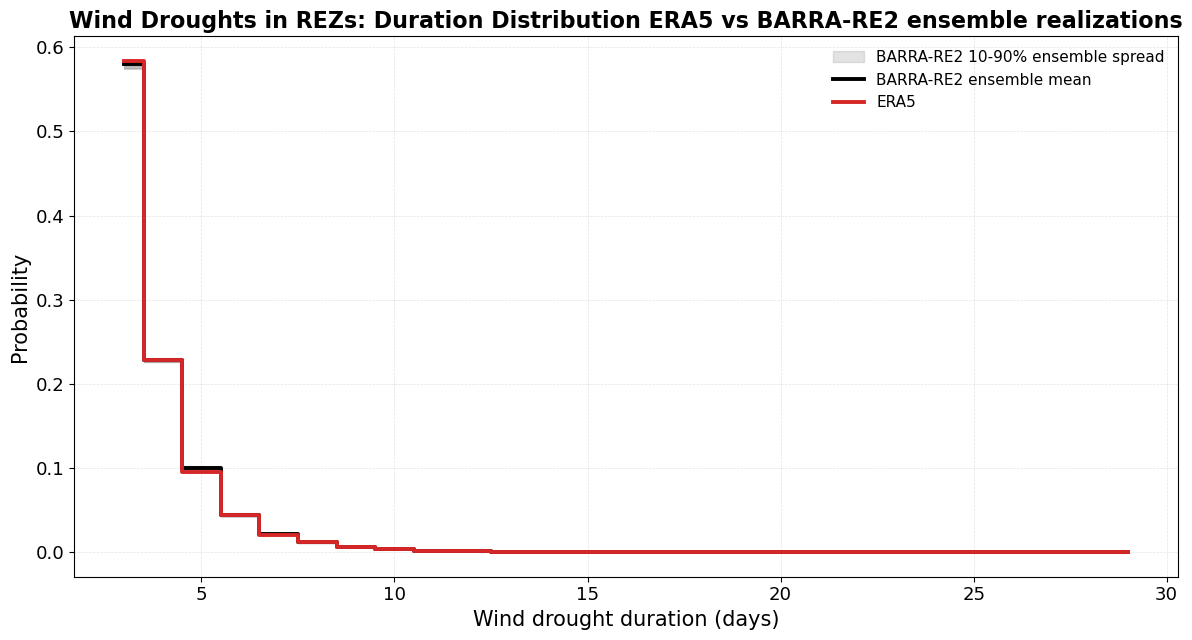

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/ensemble_realization_comparison/REZ_wind_drought_duration_distribution_ERA5_BARRA_all_realizations_spread_mean.png


In [11]:
# =====================
# Best-practice ensemble plot: grey members + spread + mean + ERA5
# =====================
fig, ax = plt.subplots(figsize=(12, 6.5))

# 10-90% BARRA spread band
ax.fill_between(
    duration_values,
    barra_p10_prob,
    barra_p90_prob,
    color="grey",
    alpha=0.22,
    step="mid",
    label="BARRA-RE2 10-90% ensemble spread"
)

# All individual BARRA realizations in the background
for r, label in enumerate(realization_values):
    ax.step(
        duration_values,
        barra_probs[r],
        where="mid",
        color="0.65",
        linewidth=0.8,
        alpha=0.45,
        zorder=1
    )

# BARRA ensemble mean probability distribution
ax.step(
    duration_values,
    barra_mean_prob,
    where="mid",
    color="black",
    linewidth=2.8,
    label="BARRA-RE2 ensemble mean",
    zorder=4
)

# ERA5 probability distribution
ax.step(
    duration_values,
    era5_prob,
    where="mid",
    color="tab:red",
    linewidth=2.8,
    label="ERA5",
    zorder=5
)

ax.set_xlabel("Wind drought duration (days)", fontsize=15)
ax.set_ylabel("Probability", fontsize=15)
ax.set_title(
    "Wind Droughts in REZs: Duration Distribution ERA5 vs BARRA-RE2 ensemble realizations",
    fontsize=16,
    fontweight="bold"
)

ax.tick_params(axis="both", labelsize=13)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
ax.legend(fontsize=11, frameon=False)

plt.tight_layout()

out_png = os.path.join(
    output_dir,
    "REZ_wind_drought_duration_distribution_ERA5_BARRA_all_realizations_spread_mean.png"
)

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_png)


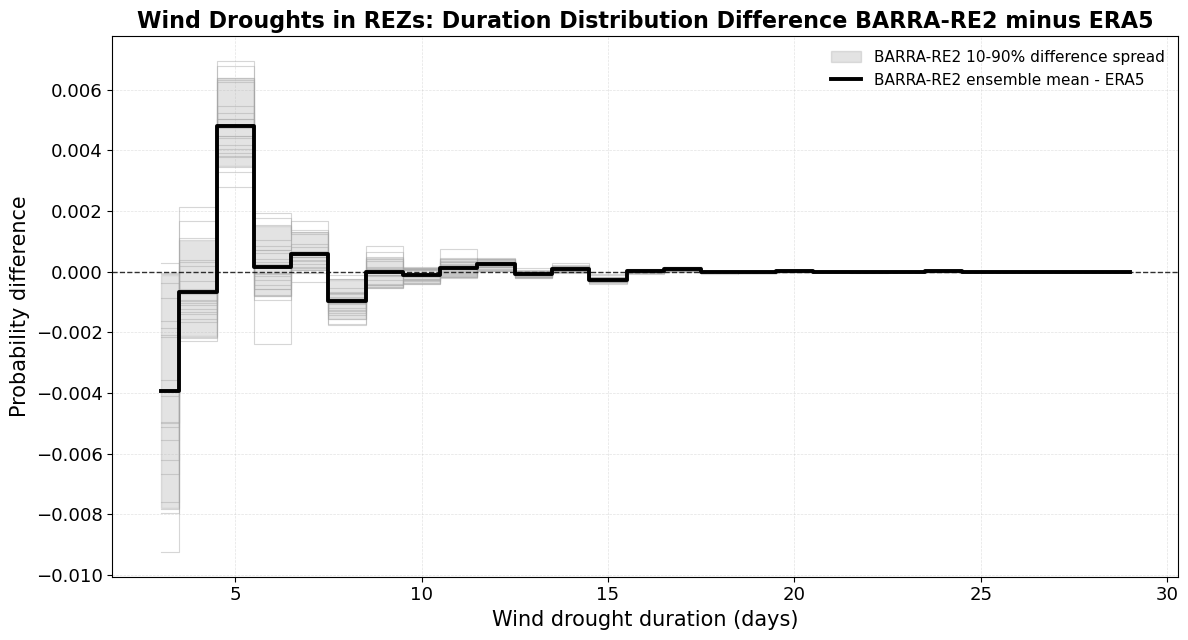

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/ensemble_realization_comparison/REZ_wind_drought_duration_distribution_BARRA_all_realizations_minus_ERA5.png


In [13]:
# =====================
# Difference plot: BARRA probability minus ERA5 probability
# =====================
barra_diff_probs = barra_probs - era5_prob[None, :]
barra_mean_diff_prob = barra_mean_prob - era5_prob
barra_p10_diff = np.nanpercentile(barra_diff_probs, 10, axis=0)
barra_p90_diff = np.nanpercentile(barra_diff_probs, 90, axis=0)

fig, ax = plt.subplots(figsize=(12, 6.5))

ax.axhline(0, color="black", linewidth=1.0, linestyle="--", alpha=0.8)

ax.fill_between(
    duration_values,
    barra_p10_diff,
    barra_p90_diff,
    color="grey",
    alpha=0.22,
    step="mid",
    label="BARRA-RE2 10-90% difference spread"
)

for r, label in enumerate(realization_values):
    ax.step(
        duration_values,
        barra_diff_probs[r],
        where="mid",
        color="0.65",
        linewidth=0.8,
        alpha=0.45,
        zorder=1
    )

ax.step(
    duration_values,
    barra_mean_diff_prob,
    where="mid",
    color="black",
    linewidth=2.8,
    label="BARRA-RE2 ensemble mean - ERA5",
    zorder=4
)

ax.set_xlabel("Wind drought duration (days)", fontsize=15)
ax.set_ylabel("Probability difference", fontsize=15)
ax.set_title(
    "Wind Droughts in REZs: Duration Distribution Difference BARRA-RE2 minus ERA5",
    fontsize=16,
    fontweight="bold"
)

ax.tick_params(axis="both", labelsize=13)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.35)
ax.legend(fontsize=11, frameon=False)

plt.tight_layout()

out_diff_png = os.path.join(
    output_dir,
    "REZ_wind_drought_duration_distribution_BARRA_all_realizations_minus_ERA5.png"
)

plt.savefig(out_diff_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_diff_png)


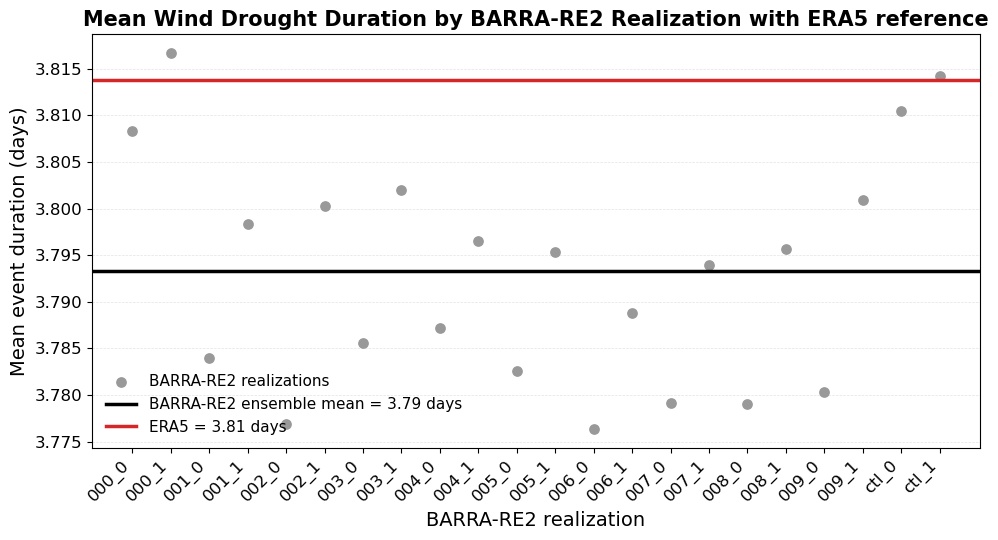

Saved: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/duration_analysis/ensemble_realization_comparison/REZ_mean_event_duration_by_BARRA_realization_with_ERA5_reference.png


In [15]:
# =====================
# Optional summary figure: member mean duration spread with ERA5 reference
# =====================
member_mean_duration = np.array([
    np.mean(d) for d in barra_durations_by_realization
])

era5_mean_duration = np.mean(era5_durations)
barra_ensemble_mean_duration = member_mean_duration.mean()

fig, ax = plt.subplots(figsize=(10, 5.5))

x = np.arange(n_real)

ax.scatter(
    x,
    member_mean_duration,
    color="0.6",
    s=45,
    label="BARRA-RE2 realizations",
    zorder=2
)

ax.axhline(
    barra_ensemble_mean_duration,
    color="black",
    linewidth=2.5,
    label=f"BARRA-RE2 ensemble mean = {barra_ensemble_mean_duration:.2f} days"
)

ax.axhline(
    era5_mean_duration,
    color="tab:red",
    linewidth=2.5,
    label=f"ERA5 = {era5_mean_duration:.2f} days"
)

ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in realization_values], rotation=45, ha="right")
ax.set_xlabel("BARRA-RE2 realization", fontsize=14)
ax.set_ylabel("Mean event duration (days)", fontsize=14)
ax.set_title(
    "Mean Wind Drought Duration by BARRA-RE2 Realization with ERA5 reference",
    fontsize=15,
    fontweight="bold"
)

ax.tick_params(axis="both", labelsize=12)
ax.grid(True, axis="y", linestyle="--", linewidth=0.5, alpha=0.35)
ax.legend(fontsize=11, frameon=False)

plt.tight_layout()

out_summary_png = os.path.join(
    output_dir,
    "REZ_mean_event_duration_by_BARRA_realization_with_ERA5_reference.png"
)

plt.savefig(out_summary_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_summary_png)


## Interpretation note

For event-duration distributions, the cleanest ensemble comparison is **not** to pool all BARRA events and show one bar. Pooling hides spread among realizations.

This notebook therefore uses:

- grey lines = individual BARRA-RE2 realization distributions
- grey band = 10-90% BARRA ensemble range
- black line = BARRA-RE2 ensemble-mean distribution
- red line = ERA5 distribution

This makes it easy to see whether ERA5 falls inside the BARRA ensemble spread, and whether the BARRA mean is shifted toward shorter or longer drought events.
